In [1]:
%pip install yfinance pandas openpyxl matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd

In [4]:
pnw_portfolio = {
    "MSFT": "Microsoft Corp. (Redmond, WA)",
    "NKE": "Nike Inc. (Beaverton, OR)",
    "INTC": "Intel Corp. (Hillsboro, OR)",
    "BA": "Boeing Co. (Puget Sound, WA)"
}

In [5]:
print("Environment setup successful! Tickers loaded:")
for ticker, location in pnw_portfolio.items():
    print(f"- {ticker}: {location}")

Environment setup successful! Tickers loaded:
- MSFT: Microsoft Corp. (Redmond, WA)
- NKE: Nike Inc. (Beaverton, OR)
- INTC: Intel Corp. (Hillsboro, OR)
- BA: Boeing Co. (Puget Sound, WA)


In [6]:
def analyze_pnw_credit(ticker):
    company = yf.Ticker(ticker)
    bs = company.balance_sheet
    inc = company.financials
    
    def get_val(df, keys):
        for k in keys:
            if k in df.index:
                return df.loc[k].iloc[0]
        return 0.0

    assets = get_val(bs, ['Total Assets'])
    liab = get_val(bs, ['Total Liabilities Net Minority Interest', 'Total Liabilities'])
    eq = get_val(bs, ['Stockholders Equity', 'Total Equity Gross Minority Interest'])
    wc = get_val(bs, ['Working Capital'])
    re = get_val(bs, ['Retained Earnings'])
    cash = get_val(bs, ['Cash And Cash Equivalents', 'Cash Cash Equivalents And Short Term Investments'])
    debt = get_val(bs, ['Total Debt'])
    
    ebit = get_val(inc, ['EBIT', 'Operating Income'])
    interest = abs(get_val(inc, ['Interest Expense', 'Interest Expense Non Operating']))
    rev = get_val(inc, ['Total Revenue'])

    coverage = round(ebit / interest, 2) if interest != 0 else 999.0
    net_debt_m = round((debt - cash) / 1e6, 2)
    
    a = assets if assets != 0 else 1.0
    x1, x2, x3, x4, x5 = wc/a, re/a, ebit/a, eq/(liab if liab != 0 else 1.0), rev/a
    z = round((1.2 * x1) + (1.4 * x2) + (3.3 * x3) + (0.6 * x4) + (0.999 * x5), 2)
    
    status = "Safe / Low Risk" if z > 2.99 else ("Grey Zone" if z > 1.81 else "Distress / High Risk")

    return {
        "Ticker": ticker,
        "Interest Coverage": coverage,
        "Net Debt ($M)": net_debt_m,
        "Altman Z-Score": z,
        "Credit Profile": status
    }

# Run loop across PNW Portfolio
results = [analyze_pnw_credit(t) for t in pnw_portfolio.keys()]
df_output = pd.DataFrame(results)

In [7]:
display(df_output)

,Ticker,Interest Coverage,Net Debt ($M),Altman Z-Score,Credit Profile
0,MSFT,55.39,35891.0,2.68,Grey Zone
1,NKE,999.00,3470.0,2.28,Grey Zone
2,INTC,2.43,32320.0,1.60,Distress / High Risk
3,BA,1.95,43512.0,0.95,Distress / High Risk


Matplotlib is building the font cache; this may take a moment.


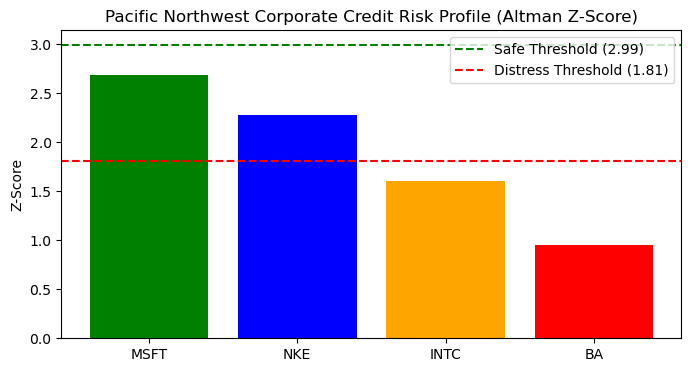

In [8]:
import matplotlib.pyplot as plt

# Plot Altman Z-Scores
plt.figure(figsize=(8, 4))
plt.bar(df_output['Ticker'], df_output['Altman Z-Score'], color=['green', 'blue', 'orange', 'red'])
plt.axhline(y=2.99, color='green', linestyle='--', label='Safe Threshold (2.99)')
plt.axhline(y=1.81, color='red', linestyle='--', label='Distress Threshold (1.81)')
plt.title('Pacific Northwest Corporate Credit Risk Profile (Altman Z-Score)')
plt.ylabel('Z-Score')
plt.legend()
plt.show()